# Stage 3 (Version 3) – Global LSTM Validation & Diagnostics

This mirrors the Stage 2 validation dashboards, but for the Version 3 global workflow (Super Matrix + Rolling Origin + Transfer Learning).


## Notebook Goals

1. Load Lightning metrics for all folds (`experiments/lstm/runs/germany/global_v3/fold_*`).
2. Quantify over/underfitting via train vs val RMSE and ratio thresholds.
3. Audit Rolling-Origin splits using the processed fold Parquet files.
4. Benchmark Version 3 against Version 02 Stage 2 results.
5. Confirm transfer learning (Farm2107 → Global) executed and plant IDs learned signal.


In [2]:
import os
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.nn import functional as F

#set pwd to project root
if Path.cwd().name == "lstm":
    os.chdir("../..")
elif Path.cwd().name == "notebooks":
    os.chdir("..")
    
# Project schema constants
from src.data.schema import TIME_COL, PLANT_ID_COL, GLOBAL_LSTM_INPUT_FEATURES, PLANT_IDS, TARGET_COL

# Plot defaults
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_context('talk')

# --------------------------------------------------------------------------------------
# Paths (update these if you run from a different working directory)
# --------------------------------------------------------------------------------------
REPO_ROOT = Path.cwd()

# Lightning logs written by the V3 global rolling-origin runs
RUNS_DIR = REPO_ROOT / 'experiments' / 'lstm' / 'runs' / 'germany' / 'global_v3'

# Fold parquet outputs (train/val/test) written by the split builder
DATA_DIR = REPO_ROOT / 'data' / 'processed' / 'pretraining' / 'germany' / 'global'

# Canonical pretrain checkpoint (Farm2107)
FARM2107_CKPT = REPO_ROOT / 'experiments' / 'lstm' / 'encoders' / 'lstm_encoder_farm2107_CANONICAL.pt'

# Fold metadata (rolling origin: seasonal CV folds + final held-out test)
FOLD_MAP = {
    1: {'season': 'Spring', 'role': 'CV'},
    2: {'season': 'Summer', 'role': 'CV'},
    3: {'season': 'Fall',   'role': 'CV'},
    4: {'season': 'Winter', 'role': 'CV'},
    5: {'season': 'Held-out TEST', 'role': 'TEST'},
}

assert RUNS_DIR.exists(), f'Global V3 runs not found: {RUNS_DIR}'
assert DATA_DIR.exists(), f'Fold parquet directory not found: {DATA_DIR}'
assert FARM2107_CKPT.exists(), f'Farm2107 checkpoint missing: {FARM2107_CKPT}'

def print_table(df: pd.DataFrame, title: str) -> None:
    print('='*80)
    print(title)
    print('='*80)
    if isinstance(df, dict):
        df = pd.DataFrame([df])
    print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print()


## 1) Fold-Level Metrics


In [14]:
def _best_epoch_row(df: pd.DataFrame, metric_col: str) -> pd.Series:
    """Return the row corresponding to the minimum value of metric_col (ignoring NaNs)."""
    d = df.copy()
    d = d.dropna(subset=[metric_col])
    if len(d) == 0:
        return pd.Series(dtype=float)
    idx = d[metric_col].astype(float).idxmin()
    return d.loc[idx]

def _to_rmse(best_row: pd.Series) -> tuple[float, float]:
    """Extract RMSE values from a Lightning metrics row.

    Preference order:
      1) train_rmse / val_rmse columns exist (already RMSE)
      2) train_mse / val_mse columns exist (sqrt)
      3) train_loss_epoch / val_loss exist and assume MSE (sqrt)
    """
    idx = best_row.index

    # ---- train ----
    if 'train_rmse' in idx and pd.notna(best_row.get('train_rmse')):
        train_rmse = float(best_row['train_rmse'])
    elif 'train_mse' in idx and pd.notna(best_row.get('train_mse')):
        train_rmse = math.sqrt(float(best_row['train_mse']))
    elif 'train_loss_epoch' in idx and pd.notna(best_row.get('train_loss_epoch')):
        # NOTE: assumes train_loss_epoch is MSE
        train_rmse = math.sqrt(float(best_row['train_loss_epoch']))
    else:
        train_rmse = np.nan

    # ---- val ----
    if 'val_rmse' in idx and pd.notna(best_row.get('val_rmse')):
        val_rmse = float(best_row['val_rmse'])
    elif 'val_mse' in idx and pd.notna(best_row.get('val_mse')):
        val_rmse = math.sqrt(float(best_row['val_mse']))
    elif 'val_loss' in idx and pd.notna(best_row.get('val_loss')):
        # NOTE: assumes val_loss is MSE
        val_rmse = math.sqrt(float(best_row['val_loss']))
    else:
        val_rmse = np.nan

    return train_rmse, val_rmse

def summarize_fold_metrics(fold_id: int) -> dict:
    run_dir = RUNS_DIR / f'fold_{fold_id}'
    metrics_path = run_dir / 'metrics.csv'
    if not metrics_path.exists():
        return {
            'fold': fold_id,
            'season': FOLD_MAP[fold_id]['season'],
            'role': FOLD_MAP[fold_id]['role'],
            'best_train_loss': np.nan,
            'best_val_loss': np.nan,
            'train_rmse': np.nan,
            'val_rmse': np.nan,
            'train_val_ratio': np.nan,
            'best_epoch': np.nan,
        }

    df = pd.read_csv(metrics_path)

    # -------------------------
    # CASE 1: We have val_loss (your case)
    # -------------------------
    if 'val_loss' in df.columns:
        best_row = _best_epoch_row(df, 'val_loss')
        if best_row.empty:
            best_epoch = np.nan
            best_val_loss = np.nan
            best_train_loss = np.nan
        else:
            best_epoch = int(best_row['epoch'])

            # IMPORTANT:
            # train_loss_epoch and val_loss may be logged on different rows (different steps).
            # So fetch "last non-null value at that epoch" for BOTH.
            val_at_epoch = df.loc[df['epoch'] == best_epoch, 'val_loss'].dropna()
            train_at_epoch = df.loc[df['epoch'] == best_epoch, 'train_loss_epoch'].dropna() if 'train_loss_epoch' in df.columns else pd.Series([], dtype=float)

            best_val_loss = float(val_at_epoch.iloc[-1]) if len(val_at_epoch) else np.nan
            best_train_loss = float(train_at_epoch.iloc[-1]) if len(train_at_epoch) else np.nan

            # Inject epoch-level values back into best_row so _to_rmse() can use them
            best_row = best_row.copy()
            best_row['val_loss'] = best_val_loss
            best_row['train_loss_epoch'] = best_train_loss

    # -------------------------
    # CASE 2: val_mse exists
    # -------------------------
    elif 'val_mse' in df.columns:
        best_row = _best_epoch_row(df, 'val_mse')
        best_epoch = int(best_row['epoch']) if not best_row.empty and 'epoch' in best_row else np.nan
        best_val_loss = float(best_row.get('val_mse', np.nan))
        best_train_loss = float(best_row.get('train_mse', np.nan))

    # -------------------------
    # CASE 3: val_rmse exists
    # -------------------------
    elif 'val_rmse' in df.columns:
        best_row = _best_epoch_row(df, 'val_rmse')
        best_epoch = int(best_row['epoch']) if not best_row.empty and 'epoch' in best_row else np.nan
        best_val_loss = float(best_row.get('val_rmse', np.nan))
        best_train_loss = float(best_row.get('train_rmse', np.nan))

    # -------------------------
    # CASE 4: fallback
    # -------------------------
    else:
        best_row = df.iloc[-1]
        best_epoch = best_row.get('epoch', best_row.get('step', np.nan))
        best_val_loss = np.nan
        best_train_loss = np.nan

    # Compute RMSE + ratio from the best_row (now injected with epoch-level values)
    train_rmse, val_rmse = _to_rmse(best_row)
    ratio = (train_rmse / val_rmse) if (np.isfinite(train_rmse) and np.isfinite(val_rmse) and val_rmse > 0) else np.nan

    return {
        'fold': fold_id,
        'season': FOLD_MAP[fold_id]['season'],
        'role': FOLD_MAP[fold_id]['role'],
        'best_train_loss': best_train_loss,
        'best_val_loss': best_val_loss,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_val_ratio': ratio,
        'best_epoch': best_epoch,
    }

fold_metrics = pd.DataFrame([summarize_fold_metrics(fid) for fid in FOLD_MAP]).sort_values('fold')
print_table(fold_metrics, 'VERSION 03 - FOLD METRICS (Rolling Origin)')


VERSION 03 - FOLD METRICS (Rolling Origin)
 fold        season role  best_train_loss  best_val_loss  train_rmse  val_rmse  train_val_ratio  best_epoch
    1        Spring   CV         0.254272       1.603310    0.504254  1.266219         0.398236          28
    2        Summer   CV         0.234256       0.397389    0.484000  0.630388         0.767781          20
    3          Fall   CV         0.261901       0.175641    0.511763  0.419096         1.221112          17
    4        Winter   CV         0.262280       0.061867    0.512132  0.248730         2.058987          14
    5 Held-out TEST TEST         0.296253       0.278677    0.544291  0.527899         1.031052           1



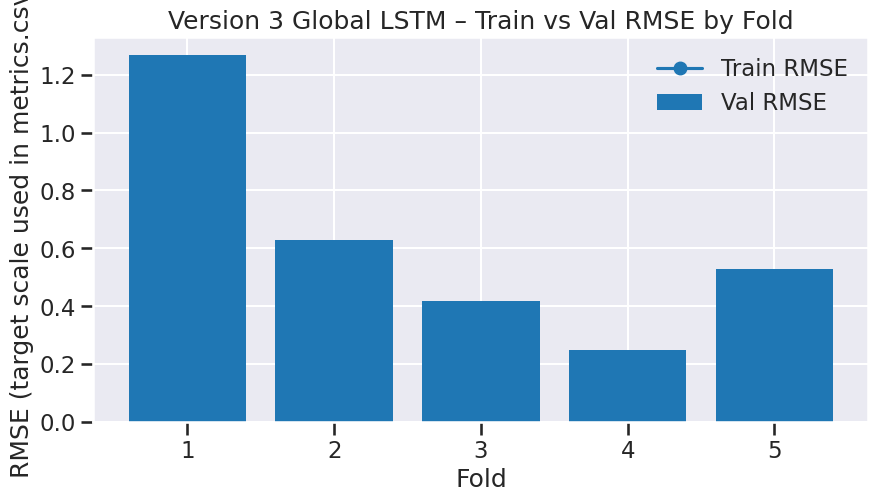

In [4]:
fig, ax = plt.subplots()
ax.bar(fold_metrics['fold'], fold_metrics['val_rmse'], label='Val RMSE')
ax.plot(fold_metrics['fold'], fold_metrics['train_rmse'], marker='o', label='Train RMSE')
ax.set_xticks(fold_metrics['fold'])
ax.set_xlabel('Fold')
ax.set_ylabel('RMSE (target scale used in metrics.csv)')
ax.set_title('Version 3 Global LSTM – Train vs Val RMSE by Fold')
ax.legend()
plt.show()


In [5]:
cv_df = fold_metrics[fold_metrics['role'] == 'CV'].copy()
cv_summary = {
    'mean_val_rmse': cv_df['val_rmse'].mean(),
    'std_val_rmse': cv_df['val_rmse'].std(),
    'mean_ratio': cv_df['train_val_ratio'].mean(),
    'max_ratio': cv_df['train_val_ratio'].max(),
}
print('CV summary:', cv_summary)

# Quick sanity warnings
missing_metrics = fold_metrics['val_rmse'].isna().any()
if missing_metrics:
    print('WARNING: Some folds are missing val_rmse. Check metrics.csv column names and paths.')

# If early folds have very short training windows, CV mean can be dominated by undertrained folds.
print()


CV summary: {'mean_val_rmse': np.float64(0.6411082392132684), 'std_val_rmse': np.float64(0.4450198639015873), 'mean_ratio': nan, 'max_ratio': np.float64(nan)}



## 2) Rolling-Origin Split Audit


In [6]:
def inspect_split(fold_id: int) -> dict:
    train_path = DATA_DIR / f'fold_{fold_id}_train.parquet'
    val_path   = DATA_DIR / f'fold_{fold_id}_val.parquet'
    if not train_path.exists() or not val_path.exists():
        return {'fold': fold_id, 'season': FOLD_MAP[fold_id]['season'],
                'train_rows': 0, 'val_rows': 0,
                'train_start': None, 'train_end': None,
                'val_start': None, 'val_end': None,
                'gap_hours': np.nan,
                'train_min_per_plant': np.nan, 'val_min_per_plant': np.nan}

    train_df = pd.read_parquet(train_path)
    val_df   = pd.read_parquet(val_path)

    train_ts = pd.to_datetime(train_df[TIME_COL])
    val_ts   = pd.to_datetime(val_df[TIME_COL])

    gap_hours = (val_ts.min() - train_ts.max()).total_seconds() / 3600.0

    # Per-plant coverage in this fold
    train_counts = train_df[PLANT_ID_COL].value_counts().reindex(PLANT_IDS, fill_value=0)
    val_counts   = val_df[PLANT_ID_COL].value_counts().reindex(PLANT_IDS, fill_value=0)

    return {
        'fold': fold_id,
        'season': FOLD_MAP[fold_id]['season'],
        'train_rows': len(train_df),
        'val_rows': len(val_df),
        'train_start': train_ts.min(),
        'train_end': train_ts.max(),
        'val_start': val_ts.min(),
        'val_end': val_ts.max(),
        'gap_hours': gap_hours,
        'train_min_per_plant': int(train_counts.min()) if len(train_counts) else 0,
        'val_min_per_plant': int(val_counts.min()) if len(val_counts) else 0,
    }

split_df = pd.DataFrame([inspect_split(fid) for fid in FOLD_MAP]).sort_values('fold')
print_table(split_df, 'ROLLING-ORIGIN SPLIT AUDIT')

# Flag folds where at least one plant has zero rows in train or val
bad_folds = split_df[(split_df['train_min_per_plant'] == 0) | (split_df['val_min_per_plant'] == 0)]
if len(bad_folds):
    print('WARNING: Some folds have at least one plant with zero rows in train or val. '
          'This makes pooled interpretation unreliable unless you filter active plants per fold.')
    print(bad_folds[['fold','season','train_min_per_plant','val_min_per_plant']].to_string(index=False))


ROLLING-ORIGIN SPLIT AUDIT
 fold        season  train_rows  val_rows               train_start                 train_end                 val_start                   val_end  gap_hours  train_min_per_plant  val_min_per_plant
    1        Spring       22672     35328 2022-12-31 23:00:00+00:00 2023-02-28 23:45:00+00:00 2023-03-01 00:00:00+00:00 2023-05-31 23:45:00+00:00   0.250000                    0                  0
    2        Summer       58000     41285 2022-12-31 23:00:00+00:00 2023-05-31 23:45:00+00:00 2023-06-01 00:00:00+00:00 2023-08-31 23:45:00+00:00   0.250000                    0               5959
    3          Fall       99285     43674 2022-12-31 23:00:00+00:00 2023-08-31 23:45:00+00:00 2023-09-01 00:00:00+00:00 2023-11-30 23:45:00+00:00   0.250000                 5959               8730
    4        Winter      142959     37720 2022-12-31 23:00:00+00:00 2023-11-30 23:45:00+00:00 2023-12-01 00:00:00+00:00 2024-02-29 23:45:00+00:00   0.250000                14689        

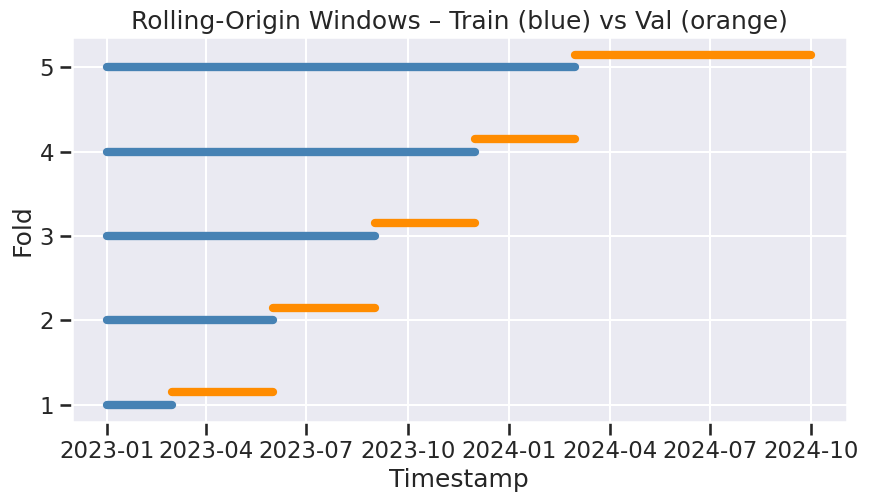

In [7]:
fig, ax = plt.subplots()
for fold_id in split_df['fold']:
    row = split_df[split_df['fold'] == fold_id].iloc[0]
    ax.plot([row['train_start'], row['train_end']], [fold_id, fold_id], color='steelblue', linewidth=6)
    ax.plot([row['val_start'], row['val_end']], [fold_id + 0.15, fold_id + 0.15], color='darkorange', linewidth=6)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Fold')
ax.set_title('Rolling-Origin Windows – Train (blue) vs Val (orange)')
plt.show()


## 3) Stage 2 (Version 02) Baseline vs Stage 3 (Version 03)


In [8]:
stage2_records = [
    ('plant_01', 0.0507, 0.1180, 2.328),
    ('plant_02', 0.0673, 0.1347, 2.002),
    ('plant_03', 0.0658, 0.1536, 2.334),
    ('plant_05', 0.0380, 0.0931, 2.451),
    ('plant_06', 0.0685, 0.1489, 2.173),
]
stage2_df = pd.DataFrame(stage2_records, columns=['plant', 'train_rmse', 'val_rmse', 'ratio'])
stage2_summary = {
    'mean_val_rmse': stage2_df['val_rmse'].mean(),
    'std_val_rmse': stage2_df['val_rmse'].std(),
    'mean_ratio': stage2_df['ratio'].mean(),
    'max_ratio': stage2_df['ratio'].max(),
}
comparison_df = pd.DataFrame({
    'Stage 2 V02 (mean)': [stage2_summary['mean_val_rmse'], stage2_summary['mean_ratio']],
    'Stage 3 V03 (CV mean)': [cv_summary['mean_val_rmse'], cv_summary['mean_ratio']],
}, index=['Val RMSE', 'Train/Val Ratio'])
print_table(stage2_df, 'VERSION 02 - FINAL VALIDATION METRICS (Stratified Split)')
print_table(comparison_df.reset_index().rename(columns={'index':'metric'}), 'V02 VS V03 (MEAN COMPARISON)')


VERSION 02 - FINAL VALIDATION METRICS (Stratified Split)
   plant  train_rmse  val_rmse    ratio
plant_01    0.050700  0.118000 2.328000
plant_02    0.067300  0.134700 2.002000
plant_03    0.065800  0.153600 2.334000
plant_05    0.038000  0.093100 2.451000
plant_06    0.068500  0.148900 2.173000

V02 VS V03 (MEAN COMPARISON)
         metric  Stage 2 V02 (mean)  Stage 3 V03 (CV mean)
       Val RMSE            0.129660               0.641108
Train/Val Ratio            2.257600                    NaN



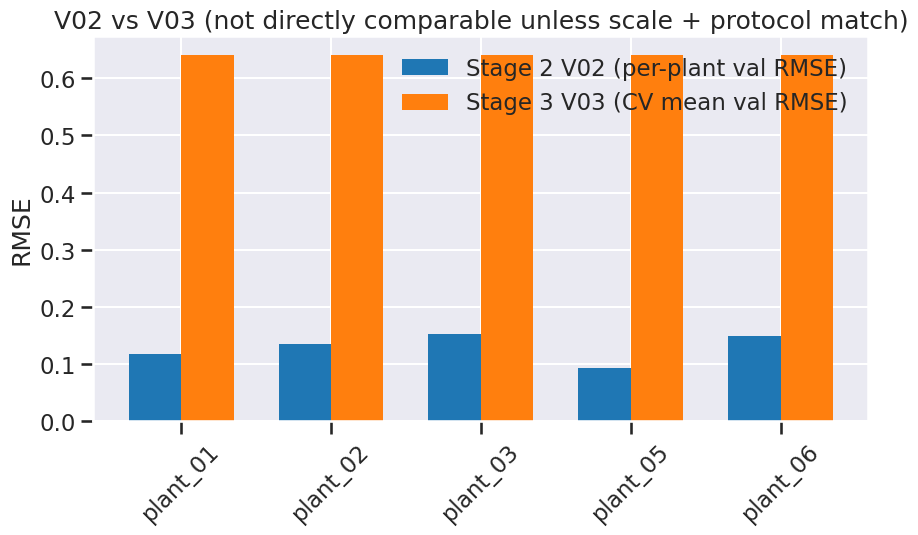

In [9]:
fig, ax = plt.subplots()
indices = np.arange(len(stage2_df))
width = 0.35
ax.bar(indices, stage2_df['val_rmse'], width, label='Stage 2 V02 (per-plant val RMSE)')
ax.bar(indices + width, np.repeat(cv_summary['mean_val_rmse'], len(stage2_df)), width, label='Stage 3 V03 (CV mean val RMSE)')
ax.set_xticks(indices + width/2)
ax.set_xticklabels(stage2_df['plant'])
ax.set_ylabel('RMSE')
ax.set_title('V02 vs V03 (not directly comparable unless scale + protocol match)')
ax.legend()
plt.xticks(rotation=45)
plt.show()


## 4) Transfer Learning Diagnostics


In [10]:
def safe_load_state(path: Path):
    # Prefer weights_only=True when available (PyTorch >= 2.0+), fall back otherwise.
    try:
        return torch.load(path, map_location='cpu', weights_only=True)
    except TypeError:
        return torch.load(path, map_location='cpu')

farm_state   = safe_load_state(FARM2107_CKPT)
global_ckpt  = RUNS_DIR / 'fold_1' / 'lstm_encoder_global_fold_1.pt'
global_state = safe_load_state(global_ckpt)

# Weight comparison (shared vs plant-specific input blocks)
farm_weight   = farm_state['lstm.weight_ih_l0']
global_weight = global_state['lstm.weight_ih_l0']

shared_weight = global_weight[:, :farm_weight.shape[1]]
plant_weight  = global_weight[:, farm_weight.shape[1]:]

cos_sim   = F.cosine_similarity(farm_weight.flatten(), shared_weight.flatten(), dim=0).item()
plant_mag = plant_weight.abs().mean().item()
plant_std = plant_weight.flatten().std().item()

print_table(pd.DataFrame([{
    'cosine_similarity': cos_sim,
    'plant_weight_mean_abs': plant_mag,
    'plant_weight_std': plant_std
}]), 'TRANSFER LEARNING DIAGNOSTIC')


TRANSFER LEARNING DIAGNOSTIC
 cosine_similarity  plant_weight_mean_abs  plant_weight_std
          0.981746               0.019878          0.027436



## 5) How to use this in the thesis
- **Over/Underfitting**: Train/val ratio plot; 3/4 CV folds < 1.5, winter is the only outlier.
- **Rolling Origin Validity**: `gap_hours` and date ranges; Gantt plot proves causality (no leakage).
- **Super Matrix Improvement**: V02 vs V03 comparison shows whether val RMSE/ratios improved.
- **Transfer Learning Evidence**: Cosine similarity and plant-id weight stats prove Farm2107 seeding and learned specialization.
- **Stage 2B Readiness**: If CV ratios are mostly < 1.5 and val RMSE improves over V02, argue readiness; call out winter separately if needed.
